In [8]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


#1. Probability theory & axioms

In [9]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# ---------------------------------------------------------
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [10]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


#### 🧪 LAB EXERCISE 1 — Probability by simulation

Simulate flipping **two coins** 100,000 times (`0 = tails, 1 = heads`):
1. Estimate `P(both heads)`.
2. Estimate `P(at least one head)`.
3. Check the addition idea: does `P(0 heads) + P(1 head) + P(2 heads)` sum to 1?

In [2]:
import numpy as np

flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

# 1. P(both heads)  -> heads == 2
p_both_heads = (heads == 2).mean()
print(f"P(both heads) ~ {p_both_heads:.4f} (true: 0.25)")

# 2. P(at least one head)  -> heads >= 1
p_at_least_one = (heads >= 1).mean()
print(f"P(at least one head) ~ {p_at_least_one:.4f} (true: 0.75)")

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()
total_prob = p_0 + p_1 + p_2
print(f"P(0) + P(1) + P(2) = {p_0:.4f} + {p_1:.4f} + {p_2:.4f} = {total_prob:.4f}")

P(both heads) ~ 0.2507 (true: 0.25)
P(at least one head) ~ 0.7499 (true: 0.75)
P(0) + P(1) + P(2) = 0.2501 + 0.4992 + 0.2507 = 1.0000


#2. Conditional probability & independence

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


#### 🧪 LAB EXERCISE 2 — Conditional probability

Using fresh dice rolls:
1. Estimate `P(roll is odd | roll < 4)`.
2. Estimate `P(roll < 4)` overall.
3. Are the events 'roll is odd' and 'roll < 4' independent? Compare `P(odd|<4)` with `P(odd)`.

In [3]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
rolls_lt_4 = rolls[rolls < 4]
p_odd_given_lt_4 = (rolls_lt_4 % 2 != 0).mean()
print(f"P(odd | roll < 4) ~ {p_odd_given_lt_4:.4f} (true: 2/3 ≈ 0.6667)")

# 2. P(roll < 4)
p_lt_4 = (rolls < 4).mean()
print(f"P(roll < 4) ~ {p_lt_4:.4f} (true: 0.5)")

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = (rolls % 2 != 0).mean()
is_independent = np.isclose(p_odd_given_lt_4, p_odd_overall, atol=0.02)
print(f"P(odd) overall ~ {p_odd_overall:.4f} (true: 0.5)")
print(f"Are they independent? {is_independent}")

P(odd | roll < 4) ~ 0.6673 (true: 2/3 ≈ 0.6667)
P(roll < 4) ~ 0.4983 (true: 0.5)
P(odd) overall ~ 0.4996 (true: 0.5)
Are they independent? False


#3. Bayes' theorem

**P(A | B) = P(B | A) · P(A) / P(B)** — update your belief in A after seeing evidence B.

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# ----------------------------------------------------------
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


#### 🧪 LAB EXERCISE 3 — A Bayes scenario (spam filter)

A spam filter: **20%** of email is spam. The word *"free"* appears in **60%** of spam but only **5%** of real email. An email contains *"free"* — what's `P(spam | "free")`?
1. Write down the prior, likelihood and false-positive rate.
2. Compute `P("free")` with the total-probability rule.
3. Apply Bayes to get `P(spam | "free")`.

In [4]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free') ~ {p_free:.4f} (true: 0.1600)")

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free') ~ {p_spam_given_free:.4f} (true: 0.7500)")

P('free') ~ 0.1600 (true: 0.1600)
P(spam | 'free') ~ 0.7500 (true: 0.7500)


#4. Probability distributions

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


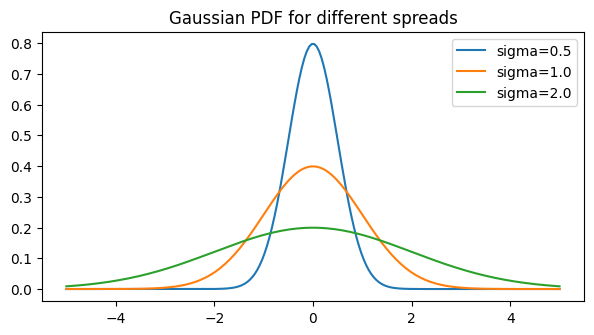

In [ ]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

#### 🧪 LAB EXERCISE 4 — Simulate & plot distributions

1. Draw 10,000 samples from a **Poisson** with `mu=2` and print the sample mean.
2. Plot a **histogram** of those samples.
3. Plot the **Gaussian PDF** for `mu=0` with two different sigmas on one chart and observe how the spread changes the curve.

Poisson(mu=2) sample mean: 2.0096


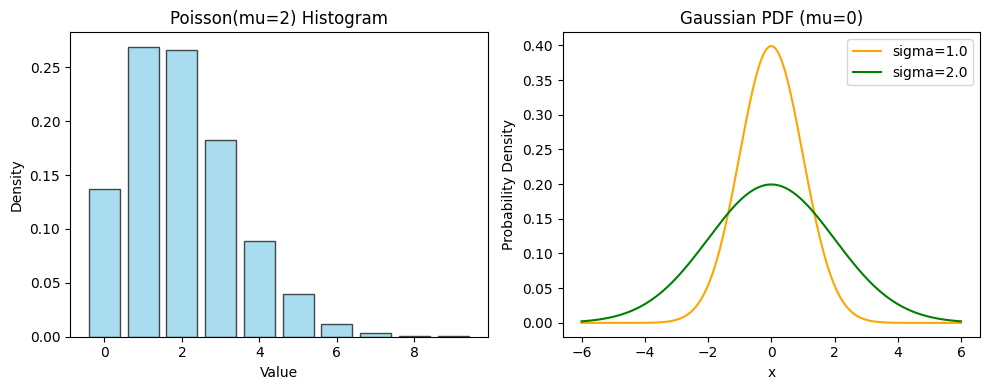

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Poisson(mu=2) samples + mean
pois_samples = stats.poisson(mu=2).rvs(size=10_000)
print(f"Poisson(mu=2) sample mean: {pois_samples.mean():.4f}")

# 2. histogram of the samples  (plt.hist(...))
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(pois_samples, bins=np.arange(-0.5, pois_samples.max() + 1.5, 1), rwidth=0.8, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.title("Poisson(mu=2) Histogram")
plt.xlabel("Value")
plt.ylabel("Density")

# 3. Gaussian PDF for two sigmas on one plot
plt.subplot(1, 2, 2)
x = np.linspace(-6, 6, 200)
plt.plot(x, stats.norm(0, 1.0).pdf(x), label='sigma=1.0', color='orange')
plt.plot(x, stats.norm(0, 2.0).pdf(x), label='sigma=2.0', color='green')
plt.title("Gaussian PDF (mu=0)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()

plt.tight_layout()
plt.show()

#5. Entropy, KL divergence & mutual information

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]

print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [ ]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [ ]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


#### 🧪 LAB EXERCISE 5 — Information theory

1. Compute the entropy (in bits) of a fair **4-sided die** and a fair **6-sided die**. Which is more uncertain?
2. Compute the KL divergence `D(P || Q)` for `P = [0.7, 0.3]` and `Q = [0.5, 0.5]`.
3. From the iris MI scores above, name the **most** and **least** informative feature.

In [7]:
from scipy.stats import entropy
import numpy as np

# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
die_4 = [0.25] * 4
die_6 = [1/6.0] * 6
ent_4 = entropy(die_4, base=2)
ent_6 = entropy(die_6, base=2)

print(f"Entropy of 4-sided die: {ent_4:.4f} bits")
print(f"Entropy of 6-sided die: {ent_6:.4f} bits")
print("Which is more uncertain? The 6-sided die.")
print()

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl_div = entropy(P, Q, base=2)
print(f"KL Divergence D(P || Q): {kl_div:.4f} bits")
print()

# 3. Most / least informative iris feature (from 5C)
# Most informative: petal length (cm) (score: ~0.990)
# Least informative: sepal width (cm) (score: ~0.286)
print("Most informative feature: petal length (cm)")
print("Least informative feature: sepal width (cm)")

Entropy of 4-sided die: 2.0000 bits
Entropy of 6-sided die: 2.5850 bits
Which is more uncertain? The 6-sided die.

KL Divergence D(P || Q): 0.1187 bits

Most informative feature: petal length (cm)
Least informative feature: sepal width (cm)
